In [13]:
#Section 2: Assignment 1 (Pakistan eCommerce Dataset)
#Dataset: Pakistans Largest eCommerce Dataset
#Target Variable: grand total
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df2 = pd.read_csv("/content/drive/MyDrive/Pakistan Largest Ecommerce Dataset.csv", on_bad_lines='skip')
df2.head()

/tmp/ipykernel_7519/2604650343.py:9: DtypeWarning: Columns (1,2,3,7,8,9,11,12,13,14,17,18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv("/content/drive/MyDrive/Pakistan Largest Ecommerce Dataset.csv", on_bad_lines='skip')


,item_id,status,created_at,sku,price,qty_ordered,grand_total,increment_id,category_name_1,sales_commission_code,...,Month,Customer Since,M-Y,FY,Customer ID,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
0,211131.0,complete,7/1/2016,kreations_YI 06-L,1950.0,1.0,1950.0,100147443,Women's Fashion,\N,...,7.0,2016-7,7-2016,FY17,1.0,NaN,NaN,NaN,NaN,NaN
1,211133.0,canceled,7/1/2016,kcc_Buy 2 Frey Air Freshener & Get 1 Kasual Bo...,240.0,1.0,240.0,100147444,Beauty & Grooming,\N,...,7.0,2016-7,7-2016,FY17,2.0,NaN,NaN,NaN,NaN,NaN
2,211134.0,canceled,7/1/2016,Ego_UP0017-999-MR0,2450.0,1.0,2450.0,100147445,Women's Fashion,\N,...,7.0,2016-7,7-2016,FY17,3.0,NaN,NaN,NaN,NaN,NaN
3,211135.0,complete,7/1/2016,kcc_krone deal,360.0,1.0,60.0,100147446,Beauty & Grooming,R-FSD-52352,...,7.0,2016-7,7-2016,FY17,4.0,NaN,NaN,NaN,NaN,NaN
4,211136.0,order_refunded,7/1/2016,BK7010400AG,555.0,2.0,1110.0,100147447,Soghaat,\N,...,7.0,2016-7,7-2016,FY17,5.0,NaN,NaN,NaN,NaN,NaN


In [14]:
#Remove all unused columns (if any)
unused_columns = [
    'sales_commission_code',
    'FY',
    'M-Y',
    'Unnamed: 21',
    'Unnamed: 22',
    'Unnamed: 23',
    'Unnamed: 24',
    'Unnamed: 25'
]
df2.drop(unused_columns, axis=1, inplace=True)
df2.head()

,item_id,status,created_at,sku,price,qty_ordered,grand_total,increment_id,category_name_1,discount_amount,payment_method,Working Date,BI Status,MV,Year,Month,Customer Since,Customer ID
0,211131.0,complete,7/1/2016,kreations_YI 06-L,1950.0,1.0,1950.0,100147443,Women's Fashion,0.0,cod,7/1/2016,#REF!,"1,950",2016.0,7.0,2016-7,1.0
1,211133.0,canceled,7/1/2016,kcc_Buy 2 Frey Air Freshener & Get 1 Kasual Bo...,240.0,1.0,240.0,100147444,Beauty & Grooming,0.0,cod,7/1/2016,Gross,240,2016.0,7.0,2016-7,2.0
2,211134.0,canceled,7/1/2016,Ego_UP0017-999-MR0,2450.0,1.0,2450.0,100147445,Women's Fashion,0.0,cod,7/1/2016,Gross,"2,450",2016.0,7.0,2016-7,3.0
3,211135.0,complete,7/1/2016,kcc_krone deal,360.0,1.0,60.0,100147446,Beauty & Grooming,300.0,cod,7/1/2016,Net,360,2016.0,7.0,2016-7,4.0
4,211136.0,order_refunded,7/1/2016,BK7010400AG,555.0,2.0,1110.0,100147447,Soghaat,0.0,cod,7/1/2016,Valid,"1,110",2016.0,7.0,2016-7,5.0


In [15]:
# 2️ Handle null values

numeric_cols = df2.select_dtypes(include=['float64', 'int64']).columns.tolist()
numeric_cols.remove('grand_total')  # Target should not be filled
for col in numeric_cols:
    df2[col].fillna(df2[col].mean())

categorical_cols = df2.select_dtypes(include=['object']).columns.tolist()
for col in categorical_cols:
    df2[col].fillna('Unknown')






In [16]:
#handle duplicates
df2.drop_duplicates(inplace=True)



In [17]:
   # check null values
df2.isnull().sum()

,0
item_id,1
status,16
created_at,1
sku,21
price,1
qty_ordered,1
grand_total,1
increment_id,1
category_name_1,165
discount_amount,1


In [18]:
#Encode categorical features efficiently
categorical_cols_small = ['payment_method', 'status', 'category_name_1']  # only important ones

df2_encoded = pd.get_dummies(df2, columns=categorical_cols_small, drop_first=True)

In [19]:
# Only numeric columns for correlation
numeric_df = df2.select_dtypes(include=['float64', 'int64'])

# Correlation matrix
corr_matrix = numeric_df.corr()

# Top 5 features most correlated with target
corr_target = corr_matrix['grand_total'].sort_values(ascending=False)[1:6]
print("Top 5 features most correlated with grand_total:\n", corr_target)

Top 5 features most correlated with grand_total:
 qty_ordered        0.753592
price              0.277094
discount_amount    0.104368
Customer ID        0.053624
item_id            0.048711
Name: grand_total, dtype: float64


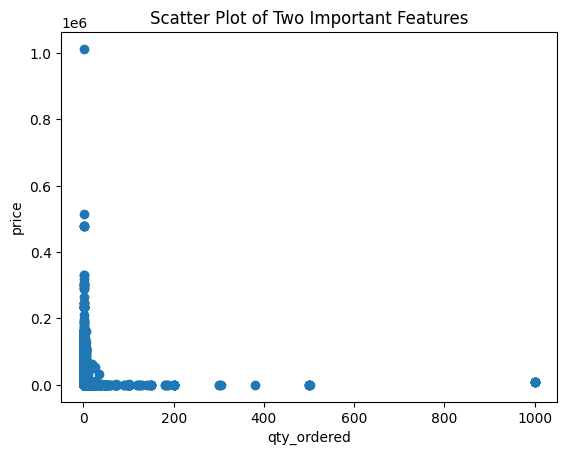

In [21]:
# 7️ Scatter plot of two important features
feature1 = corr_target.index[0]
feature2 = corr_target.index[1]

plt.scatter(numeric_df[feature1], numeric_df[feature2])
plt.xlabel(feature1)
plt.ylabel(feature2)
plt.title('Scatter Plot of Two Important Features')
plt.show()


In [23]:
Q1 = df2['grand_total'].quantile(0.25)
Q3 = df2['grand_total'].quantile(0.75)
IQR = Q3 - Q1

df2 = df2.query('(@Q1 - 1.5*@IQR) <= grand_total <= (@Q3 + 1.5*@IQR)')

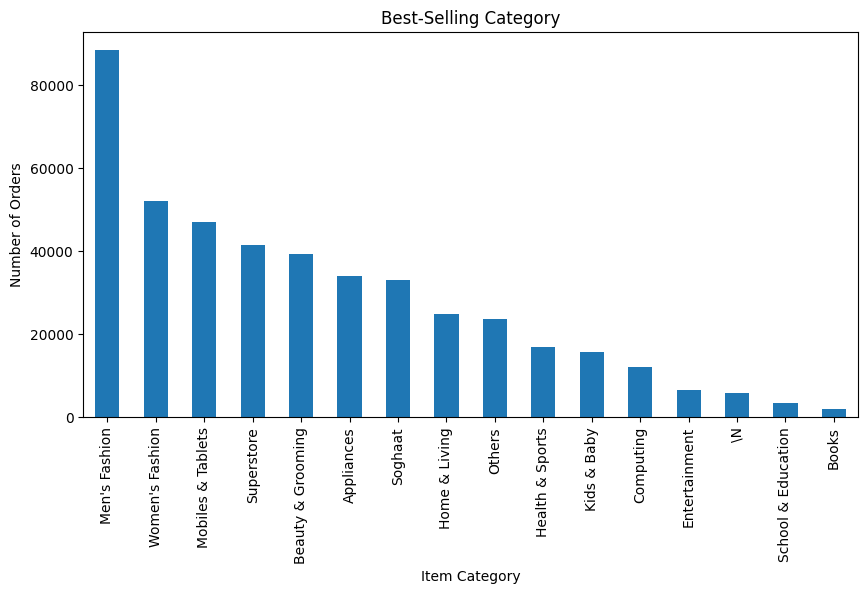

In [25]:
#Best-Selling Category
# If original 'item_category' column exists (before encoding)
if 'category_name_1' in df2.columns:
    df2['category_name_1'].value_counts().plot(kind='bar', figsize=(10,5))
    plt.title("Best-Selling Category")
    plt.xlabel("Item Category")
    plt.ylabel("Number of Orders")
    plt.show()
else:
    print("Original 'item_category' column not found. Check your preprocessing.")

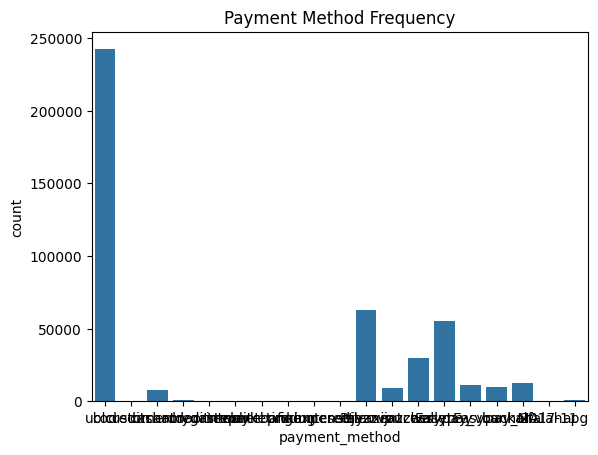

In [27]:
#visualize Payment Method and Order Status Frequency
# Payment Method Frequency
plt.title("Payment Method Frequency")
sns.countplot(x='payment_method', data=df2)
plt.show()


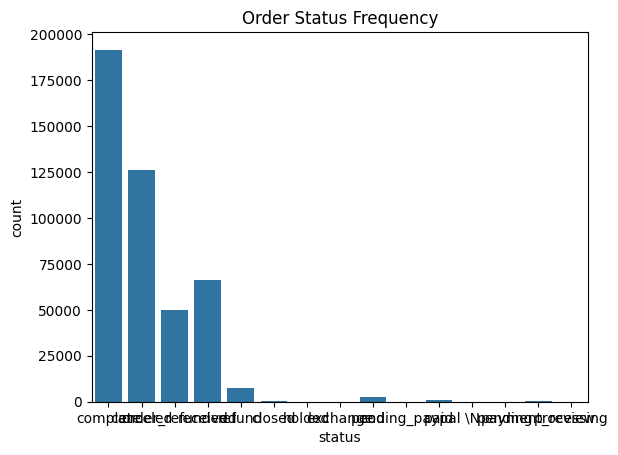

In [29]:
# Order Status Frequency
sns.countplot(x='status', data=df2)
plt.title("Order Status Frequency")
plt.show()

In [31]:
#Correlation: Payment Method vs Order Status
# Cross-tab to see relationship
payment_order_corr = pd.crosstab(df2['payment_method'], df2['status'], normalize='index')
payment_order_corr
#Shows the proportion of each order status for each payment method.
#For example, some payment methods may have higher cancellation rates.

status,\N,canceled,closed,cod,complete,exchange,holded,order_refunded,paid,payment_review,pending,pending_paypal,processing,received,refund
payment_method,,,,,,,,,,,,,,,
2017-11,0.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Easypay,0.000000,0.610687,0.000072,0.00000,0.231809,0.000000,0.000000,0.027624,0.002645,0.000000,0.000000,0.000000,0.000000,0.115678,0.011484
Easypay_MA,0.000000,0.637924,0.000000,0.00000,0.214538,0.000000,0.000000,0.023641,0.003237,0.000000,0.000000,0.000000,0.000000,0.108593,0.012066
Payaxis,0.000000,0.591603,0.000317,0.00000,0.248532,0.000000,0.000079,0.037157,0.004842,0.000000,0.000000,0.000000,0.000063,0.110759,0.006647
apg,0.000000,0.743443,0.000000,0.00000,0.020492,0.000000,0.000000,0.026230,0.016393,0.000000,0.000000,0.000000,0.000000,0.192623,0.000820
bankalfalah,0.000000,0.646334,0.000080,0.00000,0.026960,0.000000,0.000000,0.028631,0.010975,0.004215,0.000000,0.000000,0.000318,0.276762,0.005726
cashatdoorstep,0.000000,0.005822,0.000000,0.00000,0.922853,0.000000,0.000000,0.040757,0.000000,0.000000,0.000000,0.000000,0.000000,0.005822,0.024745
cod,0.000017,0.059708,0.001267,0.01075,0.560557,0.000017,0.000025,0.176475,0.000000,0.000000,0.000000,0.000029,0.000078,0.170167,0.020910
customercredit,0.000000,0.006235,0.003184,0.00000,0.548952,0.000000,0.000000,0.167949,0.013001,0.000000,0.000398,0.000000,0.000000,0.230830,0.029451


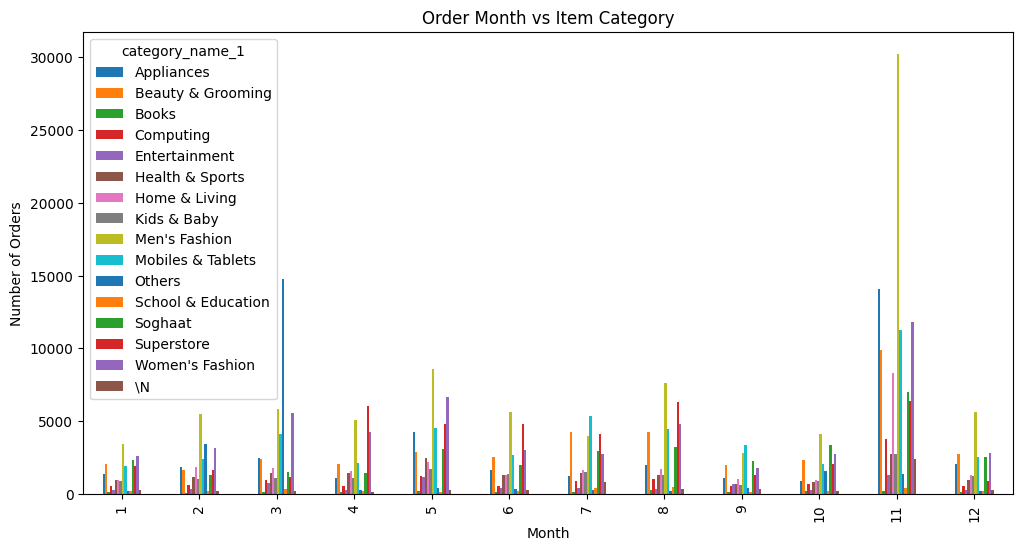

In [33]:
#Correlation: Order Date vs Item Category
# Convert order date to datetime if not already
df2['created_at'] = pd.to_datetime(df2['created_at'], errors='coerce')

# Extract month
df2['order_month'] = df2['created_at'].dt.month

# Crosstab plot
pd.crosstab(df2['order_month'], df2['category_name_1']).plot(kind='bar', figsize=(12,6))
plt.title("Order Month vs Item Category")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.show()
#Shows seasonality or monthly trends in sales for different categories.

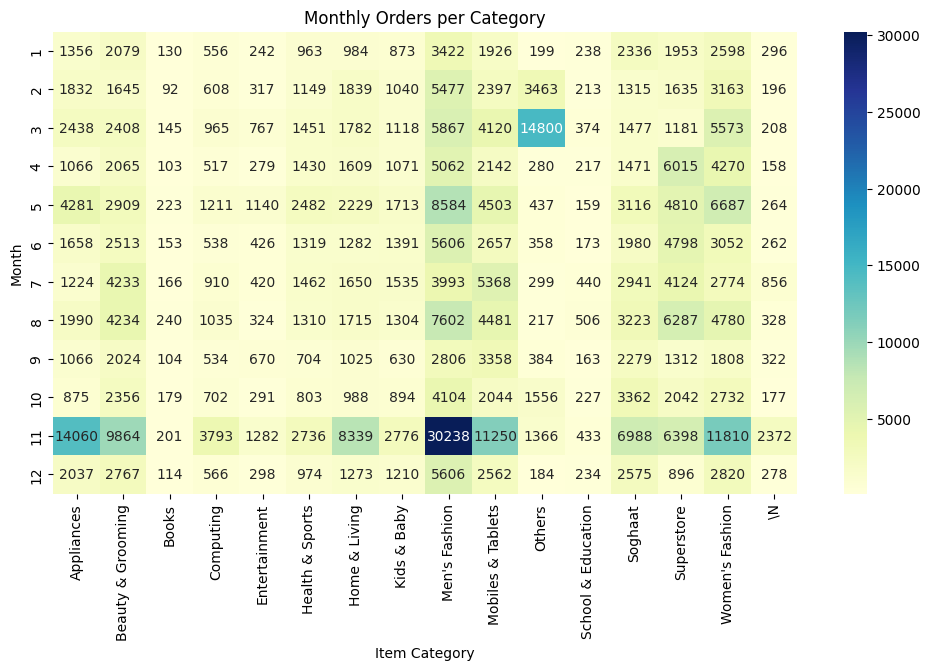

In [35]:
#Find any hidden patterns that are counter-intuitive for a layman
# Convert order date to datetime
df2['created_at'] = pd.to_datetime(df2['created_at'], errors='coerce')
df2['order_month'] = df2['created_at'].dt.month

# Count orders per category per month
month_category = df2.groupby(['order_month', 'category_name_1'])['grand_total'].count().unstack()

# Plot heatmap
plt.figure(figsize=(12,6))
sns.heatmap(month_category, cmap='YlGnBu', annot=True, fmt='d')
plt.title("Monthly Orders per Category")
plt.xlabel("Item Category")
plt.ylabel("Month")
plt.show()


In [36]:
df2.to_csv("cleaned_ecommerce_dataset.csv", index=False)